In [1]:
import torch

print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

PyTorch Version: 2.11.0+cu128
GPU Available: True
GPU Name: Tesla T4


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
os.makedirs('/content/drive/MyDrive/pneumonia_project', exist_ok=True)

In [8]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/pneumonia_project")

print(PROJECT_DIR)
print(PROJECT_DIR.exists())

/content/drive/MyDrive/pneumonia_project
True


In [9]:
import os

base_path = "/content/drive/MyDrive/pneumonia_project"

folders = [
    "data",
    "notebooks",
    "models",
    "outputs",
    "api",
    "src"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [10]:
!pip install -q kaggle

In [ ]:
import os, json

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_creds = {
    "username": "username",
    "key": "your key"
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.kaggle/kaggle.json', 600)

In [22]:
!kaggle datasets list -s pneumonia


ref                                                            title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
paultimothymooney/chest-xray-pneumonia                         Chest X-Ray Images (Pneumonia)                       2463365435  2018-03-24 19:41:59.603000         640479       7644  0.75             
pcbreviglieri/pneumonia-xray-images                            Pneumonia X-Ray Images                               1225740412  2020-05-18 14:32:09.660000          12702        102  0.9375           
iamtapendu/rsna-pneumonia-processed-dataset                    RSNA Pneumonia Processed Dataset                    11748997093  2024-11-10 17:28:20.063000           5198         35  1                


In [23]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/drive/MyDrive/pneumonia_project

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [24]:
from pathlib import Path
import zipfile

PROJECT_DIR = Path("/content/drive/MyDrive/pneumonia_project")

ZIP_PATH = PROJECT_DIR / "chest-xray-pneumonia.zip"
EXTRACT_PATH = PROJECT_DIR / "data"

# Extract only if not already extracted
if not (EXTRACT_PATH / "chest_xray").exists():
    print("Extracting dataset...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

    print("✅ Extraction completed!")

else:
    print("✅ Dataset already extracted.")

✅ Dataset already extracted.


In [25]:
for item in EXTRACT_PATH.iterdir():
    print(item)

/content/drive/MyDrive/pneumonia_project/data/chest_xray


In [26]:
from pathlib import Path

base_path = EXTRACT_PATH / "chest_xray"

print("=" * 40)
print("DATASET DISTRIBUTION")
print("=" * 40)

for split in ["train", "val", "test"]:
    print(f"\n{split.upper()} SET")

    for cls in ["NORMAL", "PNEUMONIA"]:
        path = base_path / split / cls
        count = len(list(path.iterdir()))

        print(f"{cls:<12}: {count}")

DATASET DISTRIBUTION

TRAIN SET
NORMAL      : 1341
PNEUMONIA   : 3875

VAL SET
NORMAL      : 8
PNEUMONIA   : 8

TEST SET
NORMAL      : 234
PNEUMONIA   : 390


## Observations

1. The training dataset is imbalanced:
   - Normal: 1,341 images
   - Pneumonia: 3,875 images

2. The provided validation set contains only 16 images (8 Normal, 8 Pneumonia), which is too small for reliable model evaluation.

3. The test set contains 624 images and will be reserved for final evaluation.

4. During preprocessing, a new stratified validation split will be created from the training data.

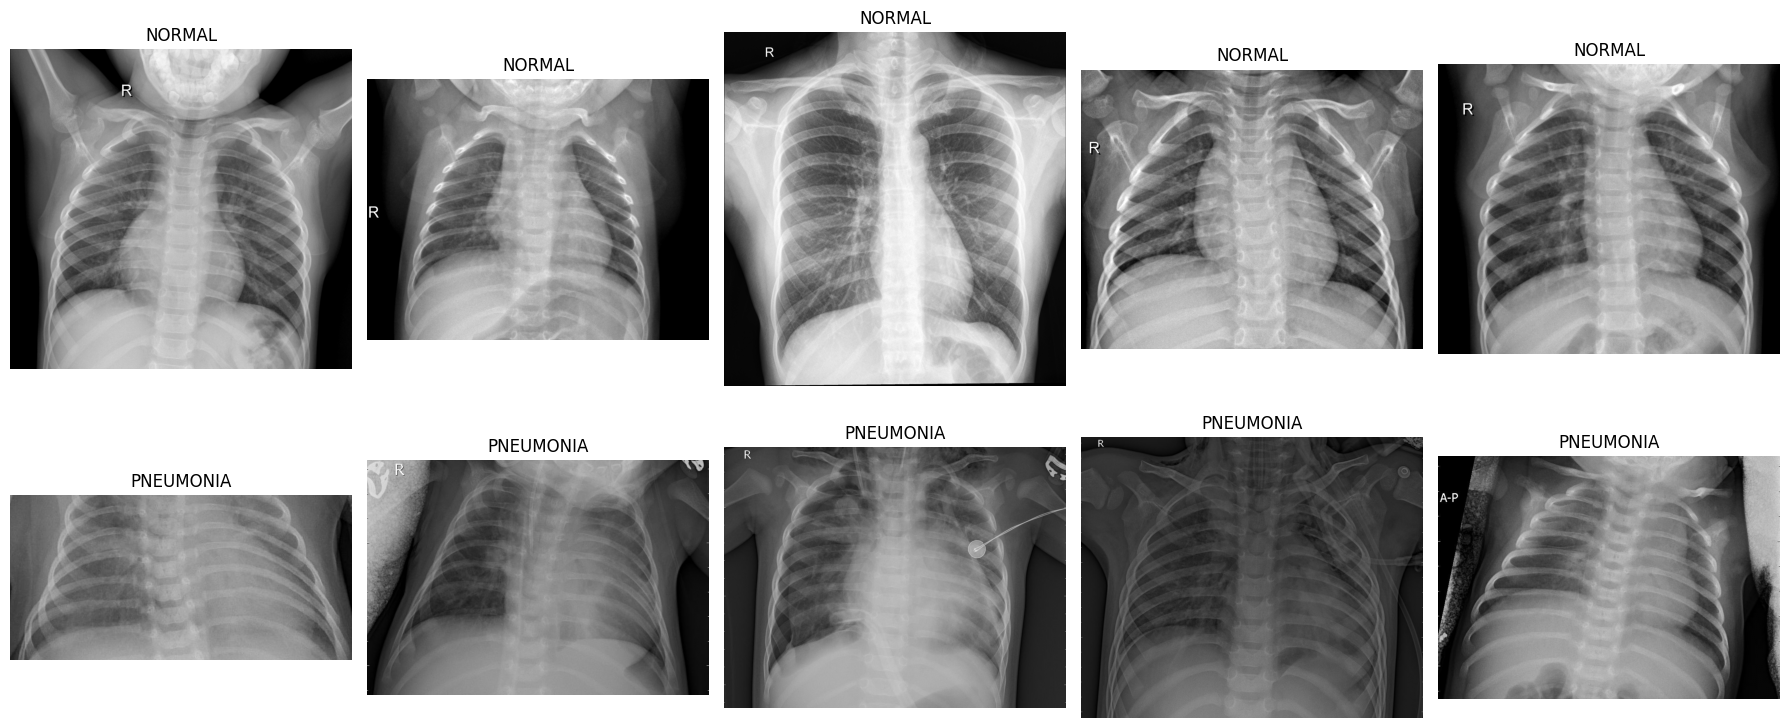

In [27]:
import matplotlib.pyplot as plt
from PIL import Image
import random

# Paths
normal_path = base_path / "train" / "NORMAL"
pneumonia_path = base_path / "train" / "PNEUMONIA"

# Select 5 random images
normal_images = random.sample(list(normal_path.iterdir()), 5)
pneumonia_images = random.sample(list(pneumonia_path.iterdir()), 5)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# Display Normal images
for i, img_path in enumerate(normal_images):
    img = Image.open(img_path)

    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title("NORMAL")
    axes[0, i].axis("off")

# Display Pneumonia images
for i, img_path in enumerate(pneumonia_images):
    img = Image.open(img_path)

    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].set_title("PNEUMONIA")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Observations

### 1. Visual Differences Between Classes

- Pneumonia images generally exhibit increased lung opacity (hazy or cloudy regions) compared to normal chest X-rays, whose lung fields appear darker due to normal air content.
- However, these differences are often subtle and not consistently obvious across all samples, indicating that the classification task is non-trivial.

### 2. Image Dimensions

- The images have varying dimensions and aspect ratios.
- A consistent input size will therefore be required before training the CNN.
- During preprocessing, all images will be resized to **224 × 224**, which matches the expected input size for pretrained CNNs such as ResNet18.

### 3. Image Artifacts

Several images contain non-anatomical artifacts, including:

- Radiology laterality markers (e.g., **"R"**)
- Medical devices such as tubes or wires
- Dark borders and scanning artifacts

These artifacts are important because a CNN may learn correlations with them instead of focusing on lung tissue.

### 4. Preprocessing Decision

The preprocessing pipeline should standardize image dimensions while preserving clinically relevant information. During model evaluation, Grad-CAM visualizations will be used to verify that the model focuses on lung regions rather than external artifacts.


In [28]:
from PIL import Image
from pathlib import Path
import pandas as pd

image_info = []

for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        folder = base_path / split / cls

        for img_path in folder.iterdir():
            try:
                with Image.open(img_path) as img:
                    width, height = img.size

                    image_info.append({
                        "split": split,
                        "class": cls,
                        "filename": img_path.name,
                        "width": width,
                        "height": height,
                        "mode": img.mode,
                        "format": img.format
                    })

            except Exception as e:
                print(f"Corrupted Image: {img_path.name}")
                print(e)

df = pd.DataFrame(image_info)

df.head()

,split,class,filename,width,height,mode,format
0,train,NORMAL,IM-0115-0001.jpeg,2090,1858,L,JPEG
1,train,NORMAL,IM-0117-0001.jpeg,1422,1152,L,JPEG
2,train,NORMAL,IM-0119-0001.jpeg,1810,1434,L,JPEG
3,train,NORMAL,IM-0122-0001.jpeg,1618,1279,L,JPEG
4,train,NORMAL,IM-0125-0001.jpeg,1600,1125,L,JPEG


In [29]:
print("Total Images:", len(df))

print("\nImage Modes:")
print(df["mode"].value_counts())

print("\nImage Formats:")
print(df["format"].value_counts())

Total Images: 5856

Image Modes:
mode
L      5573
RGB     283
Name: count, dtype: int64

Image Formats:
format
JPEG    5856
Name: count, dtype: int64


In [30]:
df[["width", "height"]].describe()

,width,height
count,5856.000000,5856.000000
mean,1327.880806,970.689037
std,363.500922,383.392117
min,384.000000,127.000000
25%,1056.000000,688.000000
50%,1281.000000,888.000000
75%,1560.000000,1187.000000
max,2916.000000,2713.000000


In [31]:
df[["width", "height"]].describe()

,width,height
count,5856.000000,5856.000000
mean,1327.880806,970.689037
std,363.500922,383.392117
min,384.000000,127.000000
25%,1056.000000,688.000000
50%,1281.000000,888.000000
75%,1560.000000,1187.000000
max,2916.000000,2713.000000


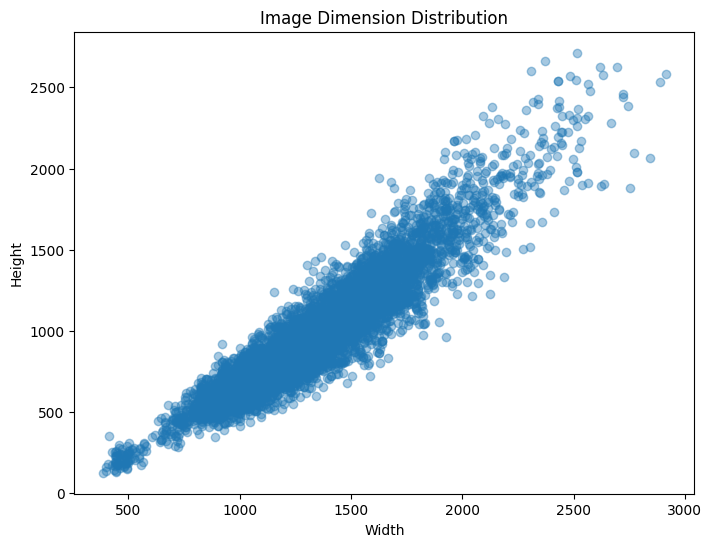

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["width"], df["height"], alpha=0.4)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Dimension Distribution")

plt.show()

In [33]:
from PIL import Image

corrupted_images = []

for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:

        folder = base_path / split / cls

        for img_path in folder.iterdir():

            try:
                with Image.open(img_path) as img:
                    img.verify()

            except Exception:
                corrupted_images.append(img_path)

print(f"Total Corrupted Images: {len(corrupted_images)}")

Total Corrupted Images: 0


## Observations

### Image Format

- All 5,856 images are stored in JPEG format.
- No additional image formats were found.

### Image Modes

- Most images (5,573) are grayscale (`L` mode).
- A small subset (283) are RGB.
- To ensure compatibility with pretrained CNNs such as ResNet18, all images will be converted to 3-channel RGB during preprocessing.

### Image Dimensions

- Image dimensions vary considerably across the dataset.
- Width ranges from **384 px** to **2916 px**.
- Height ranges from **127 px** to **2713 px**.
- Therefore, all images will be resized to **224 × 224** during preprocessing.

### Preprocessing Decisions

Based on the EDA, the preprocessing pipeline will:

- Resize all images to **224 × 224**.
- Convert grayscale images to RGB.
- Normalize pixel values using ImageNet statistics.

# Final EDA Summary

## Key Findings

- The dataset contains **5,856 chest X-ray images** divided into training, validation, and test sets.
- The training set is moderately imbalanced, with significantly more pneumonia images than normal images.
- The provided validation set contains only **16 images**, making it unsuitable for reliable model evaluation.
- Image dimensions vary considerably across the dataset, requiring resizing before training.
- Most images are grayscale (`L` mode), while a small number are RGB. All images will therefore be converted to RGB for consistency.
- All images are stored in JPEG format.
- No corrupted images were detected.
- Some images contain radiographic markers, medical devices, and scan artifacts. Grad-CAM will later be used to verify that the model focuses on lung regions instead of these artifacts.

## Decisions for the Next Phase

Based on the EDA:

- Merge the original training and validation datasets.
- Create a new stratified validation split.
- Resize all images to **224 × 224**.
- Convert all images to RGB.
- Normalize images using ImageNet statistics.
- Apply data augmentation only to the training set.

In [34]:
import os

os.makedirs("/content/drive/MyDrive/pneumonia_project/notebooks", exist_ok=True)

print("Notebook folder ready!")

Notebook folder ready!
